In [1]:
import pandas as pd
import numpy as np
from scipy.constants import pi

branch_data = pd.read_csv("branch.csv")
h_5 = 5 * 50

def create_z_5(branch_data):
    return [
        complex(row['r'], row['l'] * 2 * pi * h_5)
        for _, row in branch_data.iterrows()
    ]

def create_y_5(branch_data):
    return [
        complex(0, row['c'] * 2 * pi * h_5)
        for _, row in branch_data.iterrows()
    ]

def create_gammaL_5(branch_data, z_5, y_5):
    z_5 = np.array(z_5)
    y_5 = np.array(y_5)
    gammaL_5 = []
    for i, row in branch_data.iterrows():
        length = row['Length']
        gammaL = length * np.sqrt(z_5[i] * y_5[i])
        gammaL_5.append(gammaL)
    return gammaL_5

z_5 = create_z_5(branch_data)
y_5 = create_y_5(branch_data)
gammaL_5 = create_gammaL_5(branch_data, z_5, y_5)

def Z0_5(z_5, y_5):
    return np.sqrt(np.array(z_5) / np.array(y_5))

Z0_5 = Z0_5(z_5, y_5)
def ABCD_5(gammaL_5, Z0_5):
    A = np.cosh(gammaL_5)
    B = Z0_5 * np.sinh(gammaL_5)
    C = (1 / Z0_5) * np.sinh(gammaL_5)
    D = np.cosh(gammaL_5)
    return A, B, C, D
A_5, B_5, C_5, D_5 = ABCD_5(gammaL_5, Z0_5)
ABCD_5_df = pd.DataFrame({
    'From Bus Number': branch_data['From Bus  Number'],
    'To Bus Number'  : branch_data['To Bus  Number'],
    'A_5'           : A_5,
    'B_5'           : B_5,
    'C_5'           : C_5,
    'D_5'           : D_5
})

ABCD_5_df.to_csv("ABCD_5.csv", index=False)


In [26]:
print(z_5)
print(y_5)

[(0.027104+1.4737792332630633j), (0.027104+1.4737792332630633j), (0.040967143+1.638686144038972j), (0.040967143+1.638686144038972j), (0.038236+1.5294404011030405j), (0.038236+1.5294404011030405j), (0.076053405+1.9348220923443065j), (0.076053405+1.9348220923443065j), (0.037948173+1.5299870382247651j), (0.037948173+1.5299870382247651j), (0.038033475+1.5299210647790398j), (0.038033475+1.5299210647790398j), (0.075983717+1.9360001895894028j), (0.075983717+1.9360001895894028j), (0.0121+0.726000071096026j), (0.038070732+1.5302069497105162j), (0.037470968+1.5300640072447782j), (0.075988+1.9360001895894028j), (0.075988+1.9360001895894028j), (0.038236+1.5294404011030405j), (0.038236+1.5294404011030405j), (0.038236+1.5294404011030405j), (0.038236+1.5294404011030405j), (0.0518848+1.479104232810898j), (0.0518848+1.479104232810898j), (0.016456+1.0260802889779426j), (0.016456+1.0260802889779426j), (0.016491852+1.0271562844617972j), (0.038236+1.5294404011030405j), (0.038236+1.5294404011030405j), (0.03

In [27]:
print(Z0_5)

[277.70676023-2.55341082j 277.70676023-2.55341082j
 275.42153283-3.44223051j 275.42153283-3.44223051j
 275.42181889-3.44223407j 275.42181889-3.44223407j
 360.09759024-7.07457223j 360.09759024-7.07457223j
 275.43529689-3.41527706j 275.43529689-3.41527706j
 275.44018084-3.42316j    275.44018084-3.42316j
 360.19145181-7.06563821j 360.19145181-7.06563821j
  45.20033511-0.37664327j 275.50242697-3.42664647j
 275.27667455-3.37023069j 360.19695535-7.06614415j
 360.19695535-7.06614415j 275.42181889-3.44223407j
 275.42181889-3.44223407j 275.42181889-3.44223407j
 275.42181889-3.44223407j 275.3660902 -4.82823379j
 275.3660902 -4.82823379j  54.24593888-0.43496293j
  54.24593888-0.43496293j  54.27474449-0.4356851j
 275.42181889-3.44223407j 275.42181889-3.44223407j
 275.4420077 -3.41950452j 275.4420077 -3.41950452j
 360.14266133-7.07014177j 360.14266133-7.07014177j
 275.41827745-3.44275682j 275.41827745-3.44275682j
 360.09499142-7.07507524j 360.09499142-7.07507524j
 275.42181889-3.44223407j 275.42181

In [28]:
print(ABCD_5_df)

    From Bus Number  To Bus Number                 A_5                   B_5  \
0              2135           2220  0.992559+0.000137j  0.620299+ 33.812836j   
1              2135           2220  0.992559+0.000137j  0.620299+ 33.812836j   
2              2135           2400  0.672626+0.007705j  4.476263+203.803171j   
3              2135           2400  0.672626+0.007705j  4.476263+203.803171j   
4              2135           2970  0.960158+0.000989j  1.898206+ 76.963414j   
5              2135           2970  0.960158+0.000989j  1.898206+ 76.963414j   
6              2220           2225  0.995062+0.000194j  1.402356+ 35.735361j   
7              2220           2225  0.995062+0.000194j  1.402356+ 35.735361j   
8              2220           2230  0.986053+0.000345j  1.131617+ 45.838437j   
9              2220           2230  0.986053+0.000345j  1.131617+ 45.838437j   
10             2220           2570  0.924292+0.001858j  2.545852+105.125171j   
11             2220           2570  0.92

In [29]:
import pandas as pd
import numpy as np

# Load and ensure numeric types
ABCD = pd.read_csv("ABCD_5.csv")

# Clean column names (optional, in case there are hidden spaces)
ABCD.columns = ABCD.columns.str.strip()

# Convert to complex numbers safely
for col in ['A_5', 'B_5', 'C_5', 'D_5']:
    ABCD[col] = ABCD[col].apply(lambda x: complex(x.replace('i', 'j')) if isinstance(x, str) else complex(x))

def combine_parallel(group):
    if len(group) == 1:
        row = group.iloc[0]
        return pd.Series({
            'From Bus Number': row['From Bus Number'],
            'To Bus Number': row['To Bus Number'],
            'A': row['A_5'],
            'B': row['B_5'],
            'C': row['C_5'],
            'D': row['D_5']
        })

    # Start with first line
    A_eq, B_eq, C_eq, D_eq = group.iloc[0][['A_5', 'B_5', 'C_5', 'D_5']]
    for _, row in group.iloc[1:].iterrows():
        A1, B1, C1, D1 = A_eq, B_eq, C_eq, D_eq
        A2, B2, C2, D2 = row['A_5'], row['B_5'], row['C_5'], row['D_5']

        A_eq = (A1 * B2 + A2 * B1) / (B1 + B2)
        B_eq = (B1 * B2) / (B1 + B2)
        C_eq = C1 + C2 + ((A1 - A2) * (D1 - D2)) / (B1 + B2)
        D_eq = (D1 * B2 + D2 * B1) / (B1 + B2)

    return pd.Series({
        'From Bus Number': group.iloc[0]['From Bus Number'],
        'To Bus Number': group.iloc[0]['To Bus Number'],
        'A': A_eq, 'B': B_eq, 'C': C_eq, 'D': D_eq
    })

# Combine lines with same (From, To)
ABCD_combined = (
    ABCD.groupby(['From Bus Number', 'To Bus Number'])
    .apply(combine_parallel)
    .reset_index(drop=True)
)

# Save result
ABCD_combined.to_csv("ABCD_parallel_combined.csv", index=False)

print(ABCD_combined.shape)


(27, 6)


C:\Users\User\AppData\Local\Temp\ipykernel_11224\672773310.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_parallel)


In [30]:
import pandas as pd
import numpy as np

# Load data
ABCD_combined = pd.read_csv("ABCD_parallel_combined.csv")

def abcd2s(df):
    S_data = []

    Z0 = 360.2607461227684
    Y0 = 1 / Z0

    for _, row in df.iterrows():
        from_bus = row["From Bus Number"]
        to_bus   = row["To Bus Number"]

        A = complex(row["A"])
        B = complex(row["B"])
        C = complex(row["C"])
        D = complex(row["D"])

        denom = (A + B*Y0 + C*Z0 + D)

        S11 = (A + B*Y0 - C*Z0 - D) / denom
        S12 = 2 * (A*D - B*C) / denom
        S21 = 2 / denom
        S22 = (-A + B*Y0 - C*Z0 + D) / denom

        S = np.array([
            [S11, S12],
            [S21, S22]
        ], dtype=complex)

        S_data.append({
            "from_bus": from_bus,
            "to_bus": to_bus,
            "S": S
        })

    return S_data
S_params = abcd2s(ABCD_combined)

for i, item in enumerate(S_params):
    print(f"\nLine {i}: Bus {item['from_bus']} → Bus {item['to_bus']}")
    print(item["S"])



Line 0: Bus (2135+0j) → Bus (2220+0j)
[[-0.02353949-0.13114762j  0.97448622-0.17818419j]
 [ 0.97448622-0.17818419j -0.02353949-0.13114762j]]

Line 1: Bus (2135+0j) → Bus (2400+0j)
[[-0.54056824-0.33097366j  0.3956228 -0.65689528j]
 [ 0.3956228 -0.65689528j -0.54056824-0.33097366j]]

Line 2: Bus (2135+0j) → Bus (2970+0j)
[[-0.11785927-0.27322296j  0.8735043 -0.38158973j]
 [ 0.8735043 -0.38158973j -0.11785927-0.27322296j]]

Line 3: Bus (2220+0j) → Bus (2225+0j)
[[-0.00822655-0.07379317j  0.98858779-0.12338457j]
 [ 0.98858779-0.12338457j -0.00822655-0.07379317j]]

Line 4: Bus (2220+0j) → Bus (2230+0j)
[[-0.04405298-0.17722816j  0.9523104 -0.2411257j ]
 [ 0.9523104 -0.2411257j  -0.04405298-0.17722816j]]

Line 5: Bus (2220+0j) → Bus (2570+0j)
[[-0.20462834-0.33361586j  0.78019381-0.48381641j]
 [ 0.78019381-0.48381641j -0.20462834-0.33361586j]]

Line 6: Bus (2220+0j) → Bus (2691+0j)
[[-0.25270185-0.29857033j  0.68766833-0.60061615j]
 [ 0.68766833-0.60061615j -0.25270185-0.29857033j]]

Line 

In [31]:
import pandas as pd
import numpy as np

def connection_matrix(ABCD_combined):
    # Clean and extract unique buses
    buses = pd.unique(ABCD_combined[['From Bus Number', 'To Bus Number']].values.ravel())
    
    # Sort buses for readability (optional)
    buses = np.sort(buses)
    
    # Map bus numbers to index
    bus_index = {bus: idx for idx, bus in enumerate(buses)}
    n = len(buses)

    # Initialize connection matrix
    connection_matrix = np.zeros((n, n), dtype=int)

    # Build the adjacency (connection) matrix
    for _, row in ABCD_combined.iterrows():
        from_idx = bus_index[row['From Bus Number']]
        to_idx = bus_index[row['To Bus Number']]
        connection_matrix[from_idx, to_idx] = 1
        connection_matrix[to_idx, from_idx] = 1  # undirected

    # Create DataFrame with bus names as simple strings (robust for numeric or string types)
    bus_labels = [str(bus) for bus in buses]
    connection_df = pd.DataFrame(connection_matrix, index=bus_labels, columns=bus_labels)
    return connection_df

# Create the connection matrix DataFrame
connection_matrix_df = connection_matrix(ABCD_combined)

# Convert to NumPy array
conn_np = connection_matrix_df.to_numpy()

print(conn_np)
print("Shape:", conn_np.shape)

[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
 [0 1 0 0 

In [32]:
def connection_matrix_with_labels(ABCD_combined):
    # Extract unique buses
    buses = pd.unique(ABCD_combined[['From Bus Number', 'To Bus Number']].values.ravel())
    buses = np.sort(buses)
    
    # Map bus numbers to simple labels
    from_labels = {bus: f"a{i+1}" for i, bus in enumerate(buses)}
    to_labels = {bus: f"b{i+1}" for i, bus in enumerate(buses)}
    
    # Map bus numbers to index
    bus_index = {bus: idx for idx, bus in enumerate(buses)}
    n = len(buses)
    
    # Initialize connection matrix
    conn_matrix = np.zeros((n, n), dtype=int)
    
    # Fill matrix
    for _, row in ABCD_combined.iterrows():
        from_idx = bus_index[row['From Bus Number']]
        to_idx = bus_index[row['To Bus Number']]
        conn_matrix[from_idx, to_idx] = 1
        conn_matrix[to_idx, from_idx] = 1  # undirected
    
    # Create DataFrame with new labels
    from_bus_labels = [from_labels[bus] for bus in buses]
    to_bus_labels = [to_labels[bus] for bus in buses]
    conn_df = pd.DataFrame(conn_matrix, index=from_bus_labels, columns=to_bus_labels)
    
    return conn_df

# Example usage:
connection_matrix_df = connection_matrix_with_labels(ABCD_combined)
print(connection_matrix_df)

     b1  b2  b3  b4  b5  b6  b7  b8  b9  b10  ...  b17  b18  b19  b20  b21  \
a1    0   1   0   0   0   0   0   0   0    0  ...    0    0    0    0    0   
a2    1   0   0   1   1   0   0   0   0    0  ...    0    0    1    0    1   
a3    0   0   0   0   0   0   0   0   0    0  ...    0    0    0    0    0   
a4    0   1   0   0   0   0   0   0   0    0  ...    0    0    0    0    0   
a5    0   1   0   0   0   1   0   0   0    0  ...    0    0    0    0    0   
a6    0   0   0   0   1   0   0   1   0    0  ...    0    0    0    0    0   
a7    0   0   0   0   0   0   0   0   1    0  ...    0    0    0    0    0   
a8    0   0   0   0   0   1   0   0   0    0  ...    0    0    0    0    0   
a9    0   0   0   0   0   0   1   0   0    1  ...    0    0    0    0    0   
a10   0   0   0   0   0   0   0   0   1    0  ...    0    0    0    0    0   
a11   0   0   1   0   0   0   0   0   0    0  ...    0    0    1    0    0   
a12   0   0   0   0   0   0   0   0   0    0  ...    0    0    0

In [33]:
buses = np.sort(pd.unique(ABCD_combined[['From Bus Number', 'To Bus Number']].values.ravel()))
for i, bus in enumerate(buses):
    print(f"a{i+1} / b{i+1} -> Bus {bus}")


a1 / b1 -> Bus (2135+0j)
a2 / b2 -> Bus (2220+0j)
a3 / b3 -> Bus (2222+0j)
a4 / b4 -> Bus (2225+0j)
a5 / b5 -> Bus (2230+0j)
a6 / b6 -> Bus (2240+0j)
a7 / b7 -> Bus (2245+0j)
a8 / b8 -> Bus (2250+0j)
a9 / b9 -> Bus (2280+0j)
a10 / b10 -> Bus (2281+0j)
a11 / b11 -> Bus (2300+0j)
a12 / b12 -> Bus (2305+0j)
a13 / b13 -> Bus (2306+0j)
a14 / b14 -> Bus (2307+0j)
a15 / b15 -> Bus (2350+0j)
a16 / b16 -> Bus (2400+0j)
a17 / b17 -> Bus (2560+0j)
a18 / b18 -> Bus (2561+0j)
a19 / b19 -> Bus (2570+0j)
a20 / b20 -> Bus (2580+0j)
a21 / b21 -> Bus (2691+0j)
a22 / b22 -> Bus (2705+0j)
a23 / b23 -> Bus (2810+0j)
a24 / b24 -> Bus (2815+0j)
a25 / b25 -> Bus (2830+0j)
a26 / b26 -> Bus (2970+0j)


In [34]:
import pandas as pd
import numpy as np

# Ensure A and B are complex numbers (they may be loaded as strings from CSV)
for col in ['A', 'B']:
    ABCD_combined[col] = ABCD_combined[col].apply(
        lambda x: complex(x) if not isinstance(x, complex) else x
    )

# Compute equivalent series impedance Z = B / A
ABCD_combined['Z_equivalent_series'] = ABCD_combined.apply(
    lambda row: row['B'] / row['A'] if row['A'] != 0 else np.nan,
    axis=1
)

print("Equivalent Series Z values recalculated from ABCD_combined:")
print(ABCD_combined[['From Bus Number', 'To Bus Number', 'Z_equivalent_series']].head())
print(len(ABCD_combined['Z_equivalent_series']))

Equivalent Series Z values recalculated from ABCD_combined:
  From Bus Number To Bus Number   Z_equivalent_series
0       (2135+0j)     (2220+0j)  0.314820+ 17.033114j
1       (2135+0j)     (2400+0j)  5.062261+151.440108j
2       (2135+0j)     (2970+0j)  1.029784+ 40.077462j
3       (2220+0j)     (2225+0j)  0.708157+ 17.956214j
4       (2220+0j)     (2230+0j)  0.581947+ 23.243201j
27


In [35]:
z_eq_array = np.array(ABCD_combined['Z_equivalent_series'], dtype=complex)

In [36]:
import numpy as np
unique_connections = branch_data.drop_duplicates(subset=['From Bus  Number', 'To Bus  Number'])
unique_line_lengths_array = unique_connections['Length'].values

# Get the 'Length' column from branch_data
line_lengths = unique_line_lengths_array

# Calculate the line series impedance
line_series_impedance = z_eq_array * line_lengths

print("Calculated Line Series Impedance (z_5 * Length):")
print(line_series_impedance)

Calculated Line Series Impedance (z_5 * Length):
[7.24086155e+00+3.91761620e+02j 7.08716568e+02+2.12016151e+04j
 5.25189642e+01+2.04395059e+03j 1.31009118e+01+3.32189958e+02j
 1.75166029e+01+6.99620338e+02j 1.05150636e+02+4.00898082e+03j
 6.37330100e+02+1.41409436e+04j 4.84333199e-02+2.90499940e+00j
 1.02964363e+01+4.12706010e+02j 3.60167300e-01+1.47053698e+01j
 2.05361636e+02+4.98013789e+03j 6.16408724e+01+2.38795789e+03j
 1.75299818e+01+6.94683565e+02j 4.06571926e+00+1.15728816e+02j
 2.05712268e-03+1.28263860e-01j 3.14175271e+00+1.91380734e+02j
 6.23574528e+00+2.48597427e+02j 6.19630152e+00+2.48685214e+02j
 1.39158752e+01+3.53816210e+02j 1.39158752e+01+3.53816210e+02j
 5.62271665e+00+2.24017660e+02j 1.47178314e+01+3.73008072e+02j
 5.55810932e+00+2.21662691e+02j 1.99532709e+02+4.95983790e+03j
 2.70017544e+02+8.53550944e+03j 8.62622986e+01+4.24045327e+03j
 4.18668522e+01+1.44682685e+03j]


In [37]:
Z0_characteristic = np.array(line_series_impedance, dtype=complex).flatten()

In [38]:
conn_df = connection_matrix_df

# Convert to numpy matrix (still 0/1)
conn_np = conn_df.values

# Number of nodes
N = conn_np.shape[0]

# Map labels "a1..a26" back to numbers 1..26
node_labels = list(conn_df.index)     # ["a1", "a2", ..., "a26"]
node_numbers = [int(label[1:]) for label in node_labels]   # strip the "a"


In [39]:
lines = []

for i in range(N):
    for j in range(i+1, N):
        if conn_np[i, j] == 1:
            bus_i = node_numbers[i]
            bus_j = node_numbers[j]
            lines.append((bus_i, bus_j))

print(lines)


[(1, 2), (1, 16), (1, 26), (2, 4), (2, 5), (2, 19), (2, 21), (3, 11), (5, 6), (6, 8), (7, 9), (7, 22), (9, 10), (11, 19), (12, 13), (12, 15), (13, 20), (14, 20), (17, 19), (18, 19), (18, 26), (19, 20), (20, 25), (21, 22), (22, 23), (23, 24), (24, 25)]


In [40]:
node_to_lines = {node: [] for node in range(1, 27)}

for line_index, (a, b) in enumerate(lines):
    node_to_lines[a].append(line_index)
    node_to_lines[b].append(line_index)

print(node_to_lines)
node_to_connected_buses = {} # Initialize an empty dictionary

for node, line_indices_list in node_to_lines.items():
    connected_buses = []
    for line_index in line_indices_list:
        # Get the (bus_a, bus_b) tuple from the global 'lines' list
        bus_a, bus_b = lines[line_index]
        
        # Add the bus that is *not* the current node to the list of connected buses
        if bus_a == node:
            connected_buses.append(bus_b)
        else:
            connected_buses.append(bus_a)
    
    # Store the list of connected bus numbers for the current node
    node_to_connected_buses[node] = connected_buses

print("Node to Connected Buses:")
print(node_to_connected_buses)

{1: [0, 1, 2], 2: [0, 3, 4, 5, 6], 3: [7], 4: [3], 5: [4, 8], 6: [8, 9], 7: [10, 11], 8: [9], 9: [10, 12], 10: [12], 11: [7, 13], 12: [14, 15], 13: [14, 16], 14: [17], 15: [15], 16: [1], 17: [18], 18: [19, 20], 19: [5, 13, 18, 19, 21], 20: [16, 17, 21, 22], 21: [6, 23], 22: [11, 23, 24], 23: [24, 25], 24: [25, 26], 25: [22, 26], 26: [2, 20]}
Node to Connected Buses:
{1: [2, 16, 26], 2: [1, 4, 5, 19, 21], 3: [11], 4: [2], 5: [2, 6], 6: [5, 8], 7: [9, 22], 8: [6], 9: [7, 10], 10: [9], 11: [3, 19], 12: [13, 15], 13: [12, 20], 14: [20], 15: [12], 16: [1], 17: [19], 18: [19, 26], 19: [2, 11, 17, 18, 20], 20: [13, 14, 19, 25], 21: [2, 22], 22: [7, 21, 23], 23: [22, 24], 24: [23, 25], 25: [20, 24], 26: [1, 18]}


In [41]:
import numpy as np

# Map (bus_a, bus_b) → line index
line_index_map = {}
for idx, (b1, b2) in enumerate(lines):
    line_index_map[(b1, b2)] = idx
    line_index_map[(b2, b1)] = idx   # undirected


In [42]:
import numpy as np

def build_junction_matrix_mismatch(line_indices, Z_char):
    
    Z = np.array(Z_char[line_indices], dtype=complex)
    n = len(Z)

    S = np.zeros((n, n), dtype=complex)

    for i in range(n):
        # Admittance of all other lines
        mask = np.arange(n) != i
        Y_rest = np.sum(1.0 / Z[mask])

        # Equivalent impedance seen from line i
        Z_eq = 1.0 / Y_rest

        # Reflection coefficient at port i
        S[i, i] = (Z_eq - Z[i]) / (Z_eq + Z[i])

        # Transmission to all other ports
        for j in range(n):
            if j != i:
                S[j, i] = (
                    (2.0 * Z_eq) / (Z_eq + Z[i])
                    * (1.0 / Z[j]) / Y_rest
                )

    return S


In [43]:
junction_matrices = {}

for bus_num, connected_buses in node_to_connected_buses.items():

    if len(connected_buses) < 2:
        continue

    line_indices = []

    for cb in connected_buses:
        key = (bus_num, cb)
        if key in line_index_map:
            line_indices.append(line_index_map[key])

    if len(line_indices) < 2:
        continue

    S_junction = build_junction_matrix_mismatch(
        line_indices,
        Z0_characteristic
    )

    junction_matrices[bus_num] = {
        "lines": line_indices,
        "S": S_junction
    }

    print(f"Bus {bus_num}, lines {line_indices}")
    print(S_junction)


Bus 1, lines [0, 1, 2]
[[ 0.6527501 -2.26345181e-03j  0.02561627+3.17800417e-04j
   0.31098219+1.73160272e-03j]
 [ 0.14529191+8.24856725e-04j -0.96947524+4.14088002e-04j
   0.00574296+1.17761091e-04j]
 [ 1.50745818-3.08830853e-03j  0.00490849+9.62875846e-05j
  -0.68327486+1.84936381e-03j]]
Bus 2, lines [0, 3, 4, 5, 6]
[[-3.01654335e-01-7.27565213e-03j  4.88415382e-01+3.64232144e-03j
   1.69699987e-01-2.58377881e-03j  2.46665622e-02-3.25335158e-04j
   6.81624572e-03+4.00806870e-05j]
 [ 4.41622408e-01-2.42395208e-03j -1.76919980e-01+8.65815811e-03j
   2.00030920e-01+1.14268339e-03j  2.90740435e-02+2.25279202e-04j
   8.03098180e-03+2.15418214e-04j]
 [ 2.09747764e-01-4.16911899e-03j  2.73436410e-01+3.83072140e-03j
  -6.08989596e-01-1.51192227e-03j  1.38112943e-02-9.16697651e-05j
   3.81607355e-03+4.74417716e-05j]
 [ 3.66034907e-02-6.83961473e-04j  4.77159950e-02+7.25306735e-04j
   1.65818402e-02-1.24073540e-04j -9.31765314e-01-1.82596269e-04j
   6.65924805e-04+9.07188174e-06j]
 [ 1.0372001

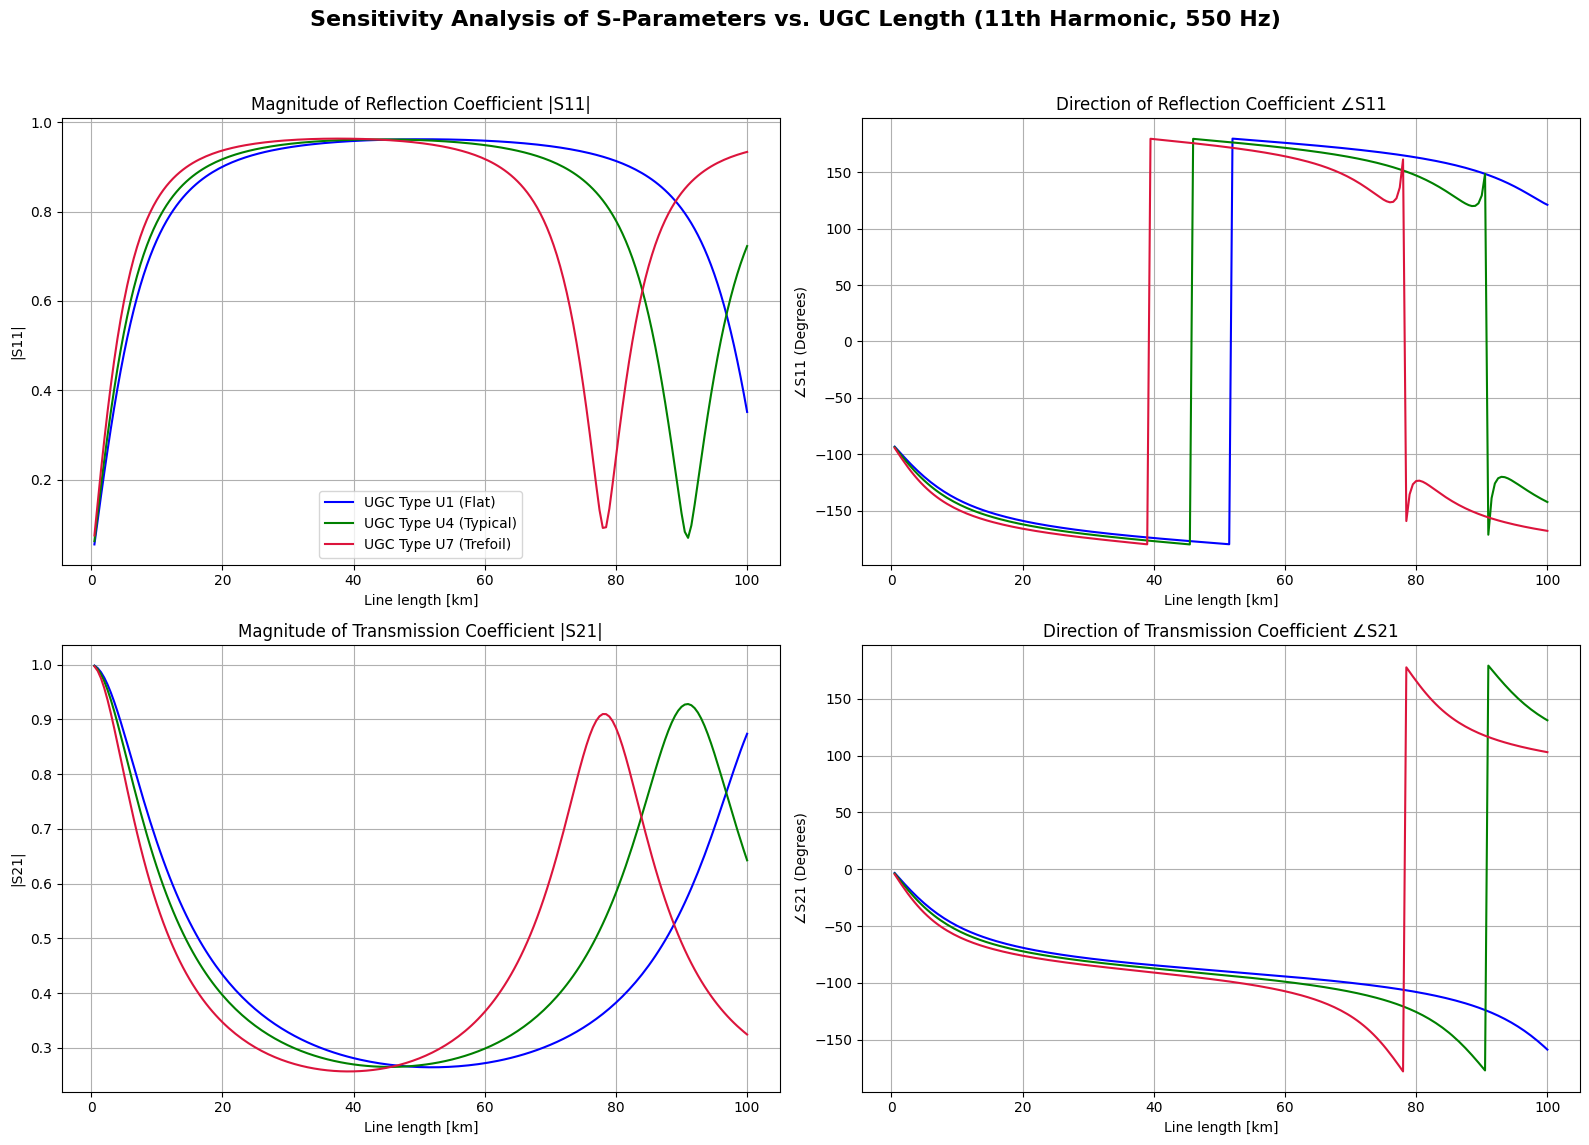

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_ugc_s_parameters(R, L, C, lengths_km, f, Z_ref):
    """
    Calculates the S11 and S21 parameters for a given cable type over an array of lengths.
    Using ABCD parameters to S-parameter conversion as defined in Chapter 4.
    """
    omega = 2 * np.pi * f
    Z_series = R + 1j * omega * L
    Y_shunt = 1j * omega * C  # Assuming G = 0
    
    Z0_line = np.sqrt(Z_series / Y_shunt)
    gamma = np.sqrt(Z_series * Y_shunt)
    
    S11_mags, S11_angles = [], []
    S21_mags, S21_angles = [], []
    
    for length in lengths_km:
        # ABCD parameters for transmission line
        A = np.cosh(gamma * length)
        B = Z0_line * np.sinh(gamma * length)
        C_param = (1/Z0_line) * np.sinh(gamma * length)
        D = A
        
        # Convert ABCD to S-parameters using Z_ref
        denom = A + B/Z_ref + C_param*Z_ref + D
        
        S11 = (A + B/Z_ref - C_param*Z_ref - D) / denom
        S21 = 2 / denom
        
        S11_mags.append(np.abs(S11))
        S11_angles.append(np.angle(S11, deg=True))
        S21_mags.append(np.abs(S21))
        S21_angles.append(np.angle(S21, deg=True))
        
    return S11_mags, S11_angles, S21_mags, S21_angles

# --- Setup Study Parameters ---
f_11th = 550.0  # 11th Harmonic (50Hz * 11)
Z_ref_ohl = 295.78  # Reference Impedance for O1 line type (from Table 4.3)
lengths = np.arange(0.5, 100.5, 0.5)  # 0.5 km to 100 km

# --- Define Cable Types (R: ohms/km, L: H/km, C: F/km) ---
# Replace these with the exact parameters from your Appendix F if available
ugc_types = {
    "UGC Type U1 (Flat)":    {'R': 0.015, 'L': 0.35e-3, 'C': 0.22e-6},
    "UGC Type U4 (Typical)": {'R': 0.018, 'L': 0.40e-3, 'C': 0.25e-6},
    "UGC Type U7 (Trefoil)": {'R': 0.025, 'L': 0.45e-3, 'C': 0.30e-6}
}

colors = ['blue', 'green', 'crimson']

# --- Calculate Data ---
results = {}
for i, (name, params) in enumerate(ugc_types.items()):
    S11_m, S11_a, S21_m, S21_a = evaluate_ugc_s_parameters(
        params['R'], params['L'], params['C'], lengths, f_11th, Z_ref_ohl
    )
    results[name] = {'S11_m': S11_m, 'S11_a': S11_a, 'S21_m': S21_m, 'S21_a': S21_a, 'color': colors[i]}

# --- Visualizations ---
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sensitivity Analysis of S-Parameters vs. UGC Length (11th Harmonic, 550 Hz)', fontsize=16, fontweight='bold')

# 1. |S11| Magnitude
for name, data in results.items():
    axs[0, 0].plot(lengths, data['S11_m'], label=name, color=data['color'])
axs[0, 0].set_title('Magnitude of Reflection Coefficient |S11|')
axs[0, 0].set_ylabel('|S11|')
axs[0, 0].set_xlabel('Line length [km]')
axs[0, 0].grid(True)
axs[0, 0].legend()

# 2. Angle of S11
for name, data in results.items():
    axs[0, 1].plot(lengths, data['S11_a'], label=name, color=data['color'])
axs[0, 1].set_title('Direction of Reflection Coefficient ∠S11')
axs[0, 1].set_ylabel('∠S11 (Degrees)')
axs[0, 1].set_xlabel('Line length [km]')
axs[0, 1].grid(True)

# 3. |S21| Magnitude
for name, data in results.items():
    axs[1, 0].plot(lengths, data['S21_m'], label=name, color=data['color'])
axs[1, 0].set_title('Magnitude of Transmission Coefficient |S21|')
axs[1, 0].set_ylabel('|S21|')
axs[1, 0].set_xlabel('Line length [km]')
axs[1, 0].grid(True)

# 4. Angle of S21
for name, data in results.items():
    axs[1, 1].plot(lengths, data['S21_a'], label=name, color=data['color'])
axs[1, 1].set_title('Direction of Transmission Coefficient ∠S21')
axs[1, 1].set_ylabel('∠S21 (Degrees)')
axs[1, 1].set_xlabel('Line length [km]')
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [1]:
import cmath
import math
import numpy as np

# System Base Values
S_base = 100e6  # 100 MVA
V_base = 220e3  # 220 kV
Z_base = (V_base ** 2) / S_base  # 484 Ohms
f_base = 50.0
f_harmonic = 250.0
h = f_harmonic / f_base
omega = 2 * math.pi * f_harmonic

# Step 1: Define line parameters (50Hz values) and Double Circuit status
line_data_raw = {
    'Line 0':  {'from': 'NPOLP_2', 'to': 'KOTMA-2', 'R': 0.001288, 'X': 0.014007, 'B': 0.04255, 'L': 23.0, 'DC': True},
    'Line 1':  {'from': 'NPOLP_2', 'to': 'HAMBAN-2', 'R': 0.01185, 'X': 0.0948, 'B': 0.2928, 'L': 140.0, 'DC': True},
    'Line 2':  {'from': 'NPOLP_2', 'to': 'PADUKKA_2', 'R': 0.004029, 'X': 0.032232, 'B': 0.099552, 'L': 51.0, 'DC': True},
    'Line 3':  {'from': 'KOTMA-2', 'to': 'UPPER-KOTH', 'R': 0.002907, 'X': 0.014791, 'B': 0.026731, 'L': 18.5, 'DC': False},
    'Line 4':  {'from': 'KOTMA-2', 'to': 'VICTO-2', 'R': 0.00236, 'X': 0.01903, 'B': 0.05877, 'L': 30.1, 'DC': True},
    'Line 5':  {'from': 'KOTMA-2', 'to': 'BIYAG-2', 'R': 0.00554, 'X': 0.04457, 'B': 0.13764, 'L': 70.5, 'DC': True},
    'Line 6':  {'from': 'KOTMA-2', 'to': 'NHAB-2', 'R': 0.01774, 'X': 0.0904, 'B': 0.16329, 'L': 113.0, 'DC': True},
    'Line 7':  {'from': 'BARGE-2', 'to': 'KELAN-2', 'R': 0.00005, 'X': 0.0006, 'B': 0.0688, 'L': 2.0, 'DC': False},
    'Line 8':  {'from': 'VICTO-2', 'to': 'RANDE-2', 'R': 0.00129, 'X': 0.01037, 'B': 0.03201, 'L': 16.4, 'DC': False},
    'Line 9':  {'from': 'RANDE-2', 'to': 'RANTE-2', 'R': 0.00024, 'X': 0.00196, 'B': 0.00606, 'L': 3.1, 'DC': False},
    'Line 10': {'from': 'VAVUNIYA-2', 'to': 'MANNAR-2', 'R': 0.01099, 'X': 0.056, 'B': 0.10115, 'L': 70.0, 'DC': False},
    'Line 11': {'from': 'VAVUNIYA-2', 'to': 'NEWANU-2', 'R': 0.004345, 'X': 0.03476, 'B': 0.10736, 'L': 55.0, 'DC': True},
    'Line 12': {'from': 'MANNAR-2', 'to': 'NADUKUDA-2', 'R': 0.00237, 'X': 0.01896, 'B': 0.05856, 'L': 30.0, 'DC': False},
    'Line 13': {'from': 'KELAN-2', 'to': 'BIYAG-2', 'R': 0.00134, 'X': 0.00764, 'B': 0.02361, 'L': 12.5, 'DC': False},
    'Line 14': {'from': 'KERAWALA_2', 'to': 'NEW_KERA2', 'R': 0.000017, 'X': 0.000212, 'B': 0.016878, 'L': 0.5, 'DC': True},
    'Line 15': {'from': 'KERAWALA_2', 'to': 'COL_L2', 'R': 0.00046, 'X': 0.00573, 'B': 0.4557, 'L': 13.5, 'DC': False},
    'Line 16': {'from': 'NEW_KERA2', 'to': 'KOTUG-2', 'R': 0.001422, 'X': 0.011376, 'B': 0.035136, 'L': 18.0, 'DC': True},
    'Line 17': {'from': 'NEW_KERA', 'to': 'KOTUG-2', 'R': 0.001413, 'X': 0.01138, 'B': 0.035143, 'L': 18.0, 'DC': True},
    'Line 18': {'from': 'PANNI-2', 'to': 'BIYAG-2', 'R': 0.00185, 'X': 0.00942, 'B': 0.01702, 'L': 15.5, 'DC': False},
    'Line 19': {'from': 'PANNI-D-2', 'to': 'BIYAG-2', 'R': 0.00185, 'X': 0.00942, 'B': 0.01702, 'L': 15.5, 'DC': False},
    'Line 20': {'from': 'PANNI-D-2', 'to': 'PADUKKA_2', 'R': 0.001517, 'X': 0.012134, 'B': 0.037478, 'L': 15.2, 'DC': True},
    'Line 21': {'from': 'BIYAG-2', 'to': 'KOTUG-2', 'R': 0.00308, 'X': 0.01567, 'B': 0.02832, 'L': 19.6, 'DC': False},
    'Line 22': {'from': 'KOTUG-2', 'to': 'VEYAN-2', 'R': 0.001343, 'X': 0.010744, 'B': 0.033184, 'L': 17.0, 'DC': False},
    'Line 23': {'from': 'NHAB-2', 'to': 'NEWANU-2', 'R': 0.00785, 'X': 0.04, 'B': 0.07225, 'L': 50.0, 'DC': False},
    'Line 24': {'from': 'NEWANU-2', 'to': 'PUTTALAM-PS', 'R': 0.009019, 'X': 0.063492, 'B': 0.185311, 'L': 100.0, 'DC': True},
    'Line 25': {'from': 'PUTTALAM-PS', 'to': 'NCHILAW-2', 'R': 0.004304, 'X': 0.04478, 'B': 0.144367, 'L': 74.0, 'DC': True},
    'Line 26': {'from': 'NCHILAW-2', 'to': 'VEYAN-2', 'R': 0.003878, 'X': 0.027302, 'B': 0.079684, 'L': 43.0, 'DC': True}
}

# Step 2: Shunt & Source Constants
bus_shunt_data = {
    "NEWANU-2":   {"P_MW": -8.658, "Q_MVAR": 11.412, "R_tx_ohm": -5590.38, "X_tx_ohm": 4241.11},
    "BIYAG-2":    {"P_MW": 69.400, "Q_MVAR": 5.100,  "R_tx_ohm": 697.41,   "X_tx_ohm": 9490.20},
    "COL_L2":     {"P_MW": 18.700, "Q_MVAR": 5.500,  "R_tx_ohm": 2588.24,  "X_tx_ohm": 8800.00},
    "VAVUNIYA-2": {"P_MW": 15.300, "Q_MVAR": 1.000,  "R_tx_ohm": 1138.82,  "X_tx_ohm": 17424.00},
    "NHAB-2":     {"P_MW": 30.400, "Q_MVAR": 5.700,  "R_tx_ohm": 573.16,   "X_tx_ohm": 3056.84},
    "HAMBAN-2":   {"P_MW": 9.300,  "Q_MVAR": 1.000,  "R_tx_ohm": 1873.55,  "X_tx_ohm": 17424.00},
    "PANNI-2":    {"P_MW": 48.500, "Q_MVAR": 15.000, "R_tx_ohm": 359.26,   "X_tx_ohm": 1161.60},
    "KELAN-2":    {"P_MW": 39.800, "Q_MVAR": 9.500,  "R_tx_ohm": 437.79,   "X_tx_ohm": 1834.11},
    "KOTUG-2":    {"P_MW": 71.300, "Q_MVAR": 21.300, "R_tx_ohm": 244.30,   "X_tx_ohm": 818.00}
}
source_buses = ["PUTTALAM-PS", "RANTE-2", "BARGE-2"]
Z_source_val = complex(1.0, (omega * 1.0) - (1.0 / (omega * 1.0)))

# Step 3: Calculate 250Hz Characteristic Impedance (Zc) per Port
nodes = {}
for line_id, p in line_data_raw.items():
    # Harmonic Scaling
    R_h = p['R']
    X_h = p['X'] * h
    B_h = p['B'] * h
    
    # Zc Calculation
    Z_phys = (complex(R_h, X_h) * Z_base) / p['L']
    Y_phys = (complex(0, B_h) / Z_base) / p['L']
    Zc = cmath.sqrt(Z_phys / Y_phys)
    
    # If Double Circuit, junction sees half the characteristic impedance
    Z_port = Zc / 2 if p['DC'] else Zc
    
    for bus in [p['from'], p['to']]:
        if bus not in nodes: nodes[bus] = {}
        nodes[bus][line_id] = Z_port

# Step 4: Final Matrix Computation Loop
node_matrices = {}
node_port_mappings = {}

for node_name, connected_ports in nodes.items():
    port_names = list(connected_ports.keys())
    
    # Add Shunt/Source as Port
    if node_name in bus_shunt_data:
        s = bus_shunt_data[node_name]
        Z_load = (V_base**2) / complex(s["P_MW"]*1e6, -s["Q_MVAR"]*1e6)
        Z_tx = complex(s["R_tx_ohm"], s["X_tx_ohm"])
        connected_ports["Shunt"] = Z_tx + Z_load
        port_names.append("Shunt")
    
    if node_name in source_buses:
        connected_ports["Source_Gen"] = Z_source_val
        port_names.append("Source_Gen")

    if len(port_names) == 1:
        connected_ports["Dummy_Open"] = complex(float('inf'), 0)
        port_names.append("Dummy_Open")

    n = len(port_names)
    node_port_mappings[node_name] = port_names
    S_mat = np.zeros((n, n), dtype=complex)
    
    for i in range(n):
        Zi = connected_ports[port_names[i]]
        Yt = sum(1/connected_ports[port_names[j]] for j in range(n) if i != j and abs(connected_ports[port_names[j]]) != float('inf'))
        Zt = 1/Yt if Yt != 0 else complex(float('inf'), 0)
        
        # S_ii (Reflection)
        if Zi == complex(float('inf'), 0): S_mat[i,i] = -1.0
        elif Zt == complex(float('inf'), 0): S_mat[i,i] = 1.0
        else: S_mat[i,i] = (Zt - Zi) / (Zt + Zi)
        
        # S_ji (Transmission)
        for j in range(n):
            if i != j:
                if Zi == complex(float('inf'), 0): S_mat[j,i] = 0.0
                elif Zt == complex(float('inf'), 0): S_mat[j,i] = 2.0
                else: S_mat[j,i] = (2 * Zt) / (Zt + Zi)

    node_matrices[node_name] = S_mat

# Display
np.set_printoptions(precision=4, suppress=True)
print(f"--- HARMONIC JUNCTION MATRICES (250 Hz, h=5) ---")
for node, matrix in node_matrices.items():
    print(f"\nJunction: {node} ({matrix.shape[0]}x{matrix.shape[1]})\nPorts: {node_port_mappings[node]}\n{matrix}")

--- HARMONIC JUNCTION MATRICES (250 Hz, h=5) ---

Junction: NPOLP_2 (3x3)
Ports: ['Line 0', 'Line 1', 'Line 2']
[[-0.337 -0.0015j  0.6685+0.0007j  0.6685+0.0007j]
 [ 0.663 -0.0015j -0.3315+0.0007j  0.6685+0.0007j]
 [ 0.663 -0.0015j  0.6685+0.0007j -0.3315+0.0007j]]

Junction: KOTMA-2 (5x5)
Ports: ['Line 0', 'Line 3', 'Line 4', 'Line 5', 'Line 6']
[[-0.5207-0.0021j  0.1848+0.0011j  0.4832-0.0006j  0.4832-0.0006j
   0.3695+0.0022j]
 [ 0.4793-0.0021j -0.8152+0.0011j  0.4832-0.0006j  0.4832-0.0006j
   0.3695+0.0022j]
 [ 0.4793-0.0021j  0.1848+0.0011j -0.5168-0.0006j  0.4832-0.0006j
   0.3695+0.0022j]
 [ 0.4793-0.0021j  0.1848+0.0011j  0.4832-0.0006j -0.5168-0.0006j
   0.3695+0.0022j]
 [ 0.4793-0.0021j  0.1848+0.0011j  0.4832-0.0006j  0.4832-0.0006j
  -0.6305+0.0022j]]

Junction: HAMBAN-2 (2x2)
Ports: ['Line 1', 'Shunt']
[[ 0.9949+0.0133j  0.0051-0.0133j]
 [ 1.9949+0.0133j -0.9949-0.0133j]]

Junction: PADUKKA_2 (2x2)
Ports: ['Line 2', 'Line 20']
[[-0.-0.j  1.+0.j]
 [ 1.-0.j  0.+0.j]]

Junct